# Synthetic validation of the donor-aware Gamma model

This notebook performs one direct validation workflow: define donor-specific Gamma rate distributions, generate Gamma–Poisson count data, fit the donor-aware Gamma model, and compare the inferred donor and population parameters with the known ground truth.

In [52]:
from __future__ import annotations

import os
import sys
from pathlib import Path

os.environ.setdefault("PYTENSOR_FLAGS", "optimizer_excluding=fusion")
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (
            candidate / "section_2" / "src" / "inference_donor_relative.py"
        ).exists():
            return candidate
    raise RuntimeError(
        "Could not find section_2/src/inference_donor_relative.py"
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
SVG_OUTPUT_DIR = PROJECT_ROOT / "section_2" / "figures" / "donor_validation"
SVG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from section_2.src import inference_donor_relative as cih

try:
    import scienceplots  # noqa: F401
    plt.style.use("science")
except ModuleNotFoundError:
    plt.style.use("default")

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/marsian/PhD_LifeSciRes/Barracuda


## 1. Define the ground truth

Each donor has a known mean rate \(\mu_{\lambda,d}\) and within-donor standard deviation \(\sigma_{\lambda,d}\). The population truth is calculated from the donor mixture, weighted by the number of simulated cells contributed by each donor.

In [53]:
OBS_TIME = 1.0
DATA_SEED = None
INFERENCE_SEED = None

DONOR_LABELS = np.arange(4)
DONOR_NUM = len(DONOR_LABELS)
CELL_NUM_BY_DONOR = np.array(
    [15, 100, 160, 220],
    dtype=int,
)

TRUE_MU_LAMBDA_DONOR = np.array([1.0, 3.0, 2.0, 1.0])
TRUE_SIGMA_LAMBDA_DONOR = np.array([0.5, 0.75, 0.6, 1.0])

DONOR_WEIGHTS = CELL_NUM_BY_DONOR / CELL_NUM_BY_DONOR.sum()
TRUE_MU_LAMBDA_POPULATION = float(
    np.sum(DONOR_WEIGHTS * TRUE_MU_LAMBDA_DONOR)
)
TRUE_SECOND_MOMENT_POPULATION = float(
    np.sum(
        DONOR_WEIGHTS
        * (
            TRUE_SIGMA_LAMBDA_DONOR**2
            + TRUE_MU_LAMBDA_DONOR**2
        )
    )
)
TRUE_SIGMA_LAMBDA_POPULATION = float(
    np.sqrt(
        TRUE_SECOND_MOMENT_POPULATION
        - TRUE_MU_LAMBDA_POPULATION**2
    )
)

donor_truth = pd.DataFrame(
    {
        "donor": DONOR_LABELS,
        "cells": CELL_NUM_BY_DONOR,
        "mu_lambda_truth": TRUE_MU_LAMBDA_DONOR,
        "sigma_lambda_truth": TRUE_SIGMA_LAMBDA_DONOR,
    }
)

population_truth = pd.DataFrame(
    {
        "parameter": ["mu_lambda", "sigma_lambda"],
        "truth": [
            TRUE_MU_LAMBDA_POPULATION,
            TRUE_SIGMA_LAMBDA_POPULATION,
        ],
    }
)

display(donor_truth)
display(population_truth.round(4))

,donor,cells,mu_lambda_truth,sigma_lambda_truth
0,0,15,1.0,0.50
1,1,100,3.0,0.75
2,2,160,2.0,0.60
3,3,220,1.0,1.00


,parameter,truth
0,mu_lambda,1.7273
1,sigma_lambda,1.1333


## 2. Generate synthetic Gamma–Poisson data

For every cell, a latent event rate is sampled from its donor-specific Gamma distribution. The observed count is then sampled from a Poisson distribution conditional on that rate.

In [54]:
rng = np.random.default_rng(DATA_SEED)
synthetic_parts = []

for donor_index, (mu_lambda, sigma_lambda, cell_num) in enumerate(
    zip(
        TRUE_MU_LAMBDA_DONOR,
        TRUE_SIGMA_LAMBDA_DONOR,
        CELL_NUM_BY_DONOR,
    )
):
    gamma_shape = (mu_lambda / sigma_lambda) ** 2
    gamma_scale = sigma_lambda**2 / mu_lambda

    latent_rate = rng.gamma(
        shape=gamma_shape,
        scale=gamma_scale,
        size=cell_num,
    )
    count = rng.poisson(
        lam=OBS_TIME * latent_rate
    )

    synthetic_parts.append(
        pd.DataFrame(
            {
                "donor": DONOR_LABELS[donor_index],
                "donor_idx": donor_index,
                "latent_rate": latent_rate,
                "count": count,
            }
        )
    )

synthetic_data = pd.concat(
    synthetic_parts,
    ignore_index=True,
)

counts = synthetic_data["count"].to_numpy(dtype=int)
donor_idx = synthetic_data["donor_idx"].to_numpy(dtype=int)

synthetic_summary = (
    synthetic_data
    .groupby("donor", as_index=False)
    .agg(
        cells=("count", "size"),
        observed_count_mean=("count", "mean"),
        observed_count_variance=("count", "var"),
        observed_rate_mean=("latent_rate", "mean"),
        observed_rate_sd=("latent_rate", "std"),
    )
)
synthetic_summary["expected_count_mean"] = (
    OBS_TIME * TRUE_MU_LAMBDA_DONOR
)
synthetic_summary["expected_count_variance"] = (
    OBS_TIME * TRUE_MU_LAMBDA_DONOR
    + OBS_TIME**2 * TRUE_SIGMA_LAMBDA_DONOR**2
)

display(synthetic_summary.round(4))
print("Total synthetic cells:", counts.size)

,donor,cells,observed_count_mean,observed_count_variance,observed_rate_mean,observed_rate_sd,expected_count_mean,expected_count_variance
0,0,15,0.9333,0.7810,1.0557,0.5397,1.0,1.2500
1,1,100,2.6900,2.8221,2.9502,0.6872,3.0,3.5625
2,2,160,2.0062,2.6981,1.9841,0.6431,2.0,2.3600
3,3,220,0.9591,1.9116,1.0222,1.0509,1.0,2.0000


Total synthetic cells: 495


## 3. Run donor-aware Gamma inference

The inference uses only the donor-aware Gamma model (`inference_Dis2P`) and runs directly on the synthetic counts.

In [55]:
LAMBDA_PRIOR_BOUNDS = (-1.0, 1.5)
STD_PRIOR_FACTOR = 3.0
# Standard deviations for donor shifts in log10(mu) and log10(sigma).
DEVIATION_PRIOR = (0.3, 0.3)

SMC_PARTICLES = 10_000
CHAINS = 6
SMC_CORES = 6

pack = cih.inference_Dis2P(
    counts,
    donor_idx,
    OBS_TIME,
    donor_num=DONOR_NUM,
    draws=SMC_PARTICLES,
    chains=CHAINS,
    cores=SMC_CORES,
    lambda_prior_bounds=LAMBDA_PRIOR_BOUNDS,
    std_prior_factor=STD_PRIOR_FACTOR,
    deviation_prior=DEVIATION_PRIOR,
    random_seed=INFERENCE_SEED,
    threshold=0.6,
    correlation_threshold=0.01,
)

idata = pack["idata"]
model = pack["model"]

SUMMARY_VARIABLES = [
    "mu_lambda_donor",
    "sigma_lambda_donor",
    "mu_lambda_population",
    "sigma_lambda_population",
]

display(
    az.summary(
        idata,
        var_names=SUMMARY_VARIABLES,
        hdi_prob=0.95,
    )
)

Initializing SMC sampler...
Sampling 6 chains in 6 jobs


Output()

/opt/homebrew/Caskroom/miniforge/base/envs/snake/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/homebrew/Caskroom/miniforge/base/envs/snake/lib/python3.13/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


                          mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  \
eta_mu_donor[0]         -0.163  0.174    -0.500      0.179      0.001   
eta_mu_donor[1]          0.245  0.155    -0.057      0.551      0.001   
eta_mu_donor[2]          0.117  0.155    -0.183      0.426      0.001   
eta_mu_donor[3]         -0.201  0.157    -0.501      0.113      0.001   
eta_sigma_donor[0]      -0.182  0.250    -0.673      0.311      0.001   
eta_sigma_donor[1]      -0.193  0.230    -0.656      0.241      0.001   
eta_sigma_donor[2]       0.026  0.200    -0.359      0.426      0.001   
eta_sigma_donor[3]       0.156  0.188    -0.212      0.525      0.001   
eta_ref                  0.183  0.154    -0.127      0.478      0.001   
sigma_lambda_ref         0.745  0.323     0.223      1.386      0.001   
mu_lambda_ref            1.624  0.592     0.659      2.818      0.002   
mu_lambda_donor[0]       1.084  0.286     0.549      1.634      0.001   
mu_lambda_donor[1]       2.687  0.171     2.354    

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_lambda_donor[0],1.084,0.286,0.549,1.634,0.001,0.001,60038.0,59851.0,1.0
mu_lambda_donor[1],2.687,0.171,2.354,3.022,0.001,0.001,59705.0,58824.0,1.0
mu_lambda_donor[2],2.002,0.127,1.746,2.244,0.001,0.000,55949.0,58399.0,1.0
mu_lambda_donor[3],0.966,0.094,0.785,1.153,0.000,0.000,59457.0,54859.0,1.0
sigma_lambda_donor[0],0.541,0.348,0.057,1.200,0.001,0.002,54982.0,53036.0,1.0
sigma_lambda_donor[1],0.496,0.233,0.095,0.938,0.001,0.001,51733.0,47643.0,1.0
sigma_lambda_donor[2],0.761,0.218,0.319,1.188,0.001,0.001,51981.0,45303.0,1.0
sigma_lambda_donor[3],0.989,0.154,0.700,1.297,0.001,0.000,59613.0,59881.0,1.0
mu_lambda_population,1.652,0.069,1.517,1.787,0.000,0.000,58401.0,58991.0,1.0
sigma_lambda_population,1.096,0.091,0.923,1.277,0.000,0.000,57496.0,47197.0,1.0


## 4. Compare the posterior with the ground truth

Recovery is assessed for the four donor-specific Gamma distributions and for the population mixture moments calculated from them.

In [56]:
def posterior_samples(
    variable: str,
    donor_index: int | None = None,
) -> np.ndarray:
    data = idata.posterior[variable]
    if donor_index is not None:
        data = data.isel(donor=donor_index)
    return np.asarray(data.values, dtype=float).reshape(-1)


def recovery_row(
    parameter: str,
    level: str,
    donor: int | str,
    truth: float,
    samples: np.ndarray,
) -> dict:
    hdi_low, hdi_high = np.asarray(
        az.hdi(samples, hdi_prob=0.95),
        dtype=float,
    ).reshape(-1)

    return {
        "parameter": parameter,
        "level": level,
        "donor": donor,
        "truth": float(truth),
        "posterior_mean": float(np.mean(samples)),
        "posterior_median": float(np.median(samples)),
        "hdi_low": float(hdi_low),
        "hdi_high": float(hdi_high),
        "truth_in_95%_hdi": bool(
            hdi_low <= truth <= hdi_high
        ),
    }


parameter_specs = {
    "mu_lambda": {
        "donor_variable": "mu_lambda_donor",
        "population_variable": "mu_lambda_population",
        "donor_truth": TRUE_MU_LAMBDA_DONOR,
        "population_truth": TRUE_MU_LAMBDA_POPULATION,
    },
    "sigma_lambda": {
        "donor_variable": "sigma_lambda_donor",
        "population_variable": "sigma_lambda_population",
        "donor_truth": TRUE_SIGMA_LAMBDA_DONOR,
        "population_truth": TRUE_SIGMA_LAMBDA_POPULATION,
    },
}

recovery_rows = []

for parameter, spec in parameter_specs.items():
    recovery_rows.append(
        recovery_row(
            parameter,
            "population",
            "population",
            spec["population_truth"],
            posterior_samples(spec["population_variable"]),
        )
    )

    for donor_index, donor_label in enumerate(DONOR_LABELS):
        recovery_rows.append(
            recovery_row(
                parameter,
                "donor",
                int(donor_label),
                spec["donor_truth"][donor_index],
                posterior_samples(
                    spec["donor_variable"],
                    donor_index,
                ),
            )
        )

recovery_table = pd.DataFrame(recovery_rows)
display(recovery_table.round(4))

,parameter,level,donor,truth,posterior_mean,posterior_median,hdi_low,hdi_high,truth_in_95%_hdi
0,mu_lambda,population,population,1.7273,1.6519,1.6502,1.5173,1.7875,True
1,mu_lambda,donor,0,1.0000,1.0843,1.0562,0.5486,1.6341,True
2,mu_lambda,donor,1,3.0000,2.6870,2.6830,2.3538,3.0221,True
3,mu_lambda,donor,2,2.0000,2.0018,1.9986,1.7460,2.2443,True
4,mu_lambda,donor,3,1.0000,0.9657,0.9608,0.7847,1.1532,True
5,sigma_lambda,population,population,1.1333,1.0957,1.0920,0.9233,1.2766,True
6,sigma_lambda,donor,0,0.5000,0.5408,0.4633,0.0566,1.2004,True
7,sigma_lambda,donor,1,0.7500,0.4958,0.4704,0.0954,0.9385,True
8,sigma_lambda,donor,2,0.6000,0.7612,0.7674,0.3187,1.1878,True
9,sigma_lambda,donor,3,1.0000,0.9888,0.9771,0.7004,1.2967,True


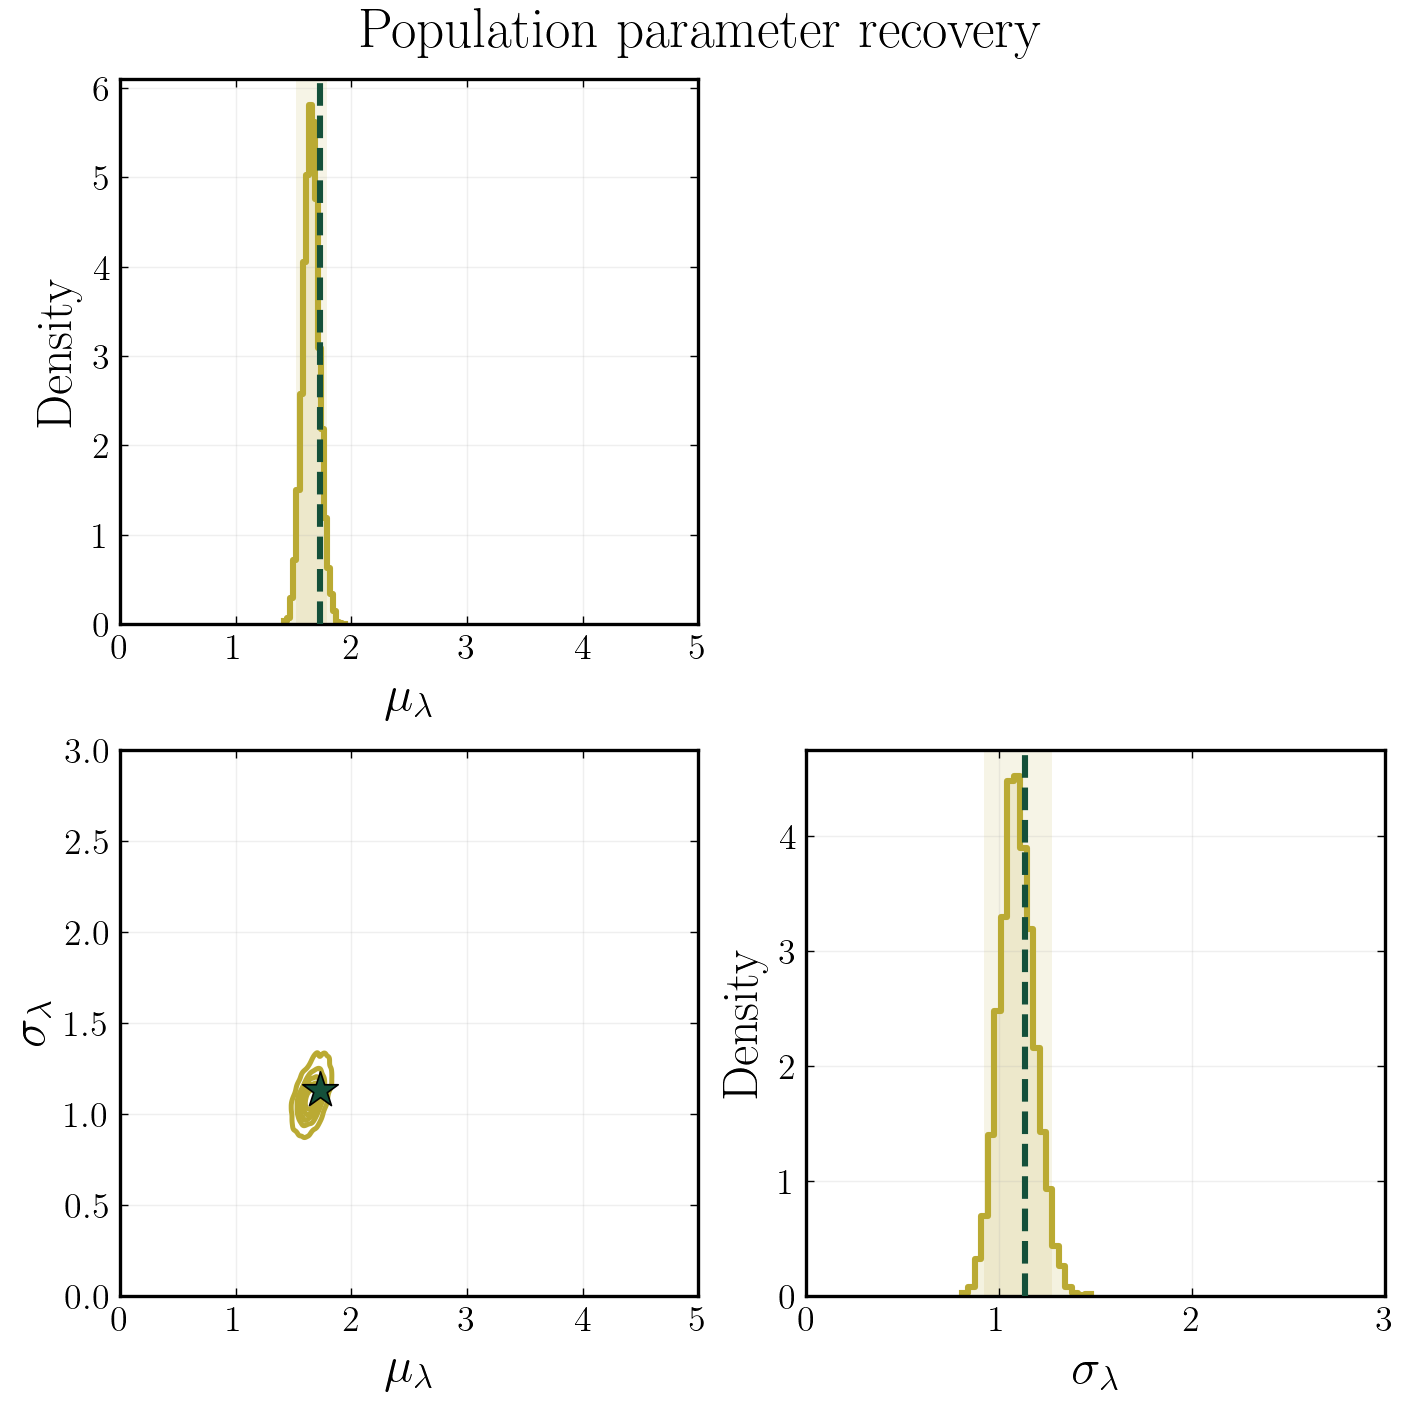

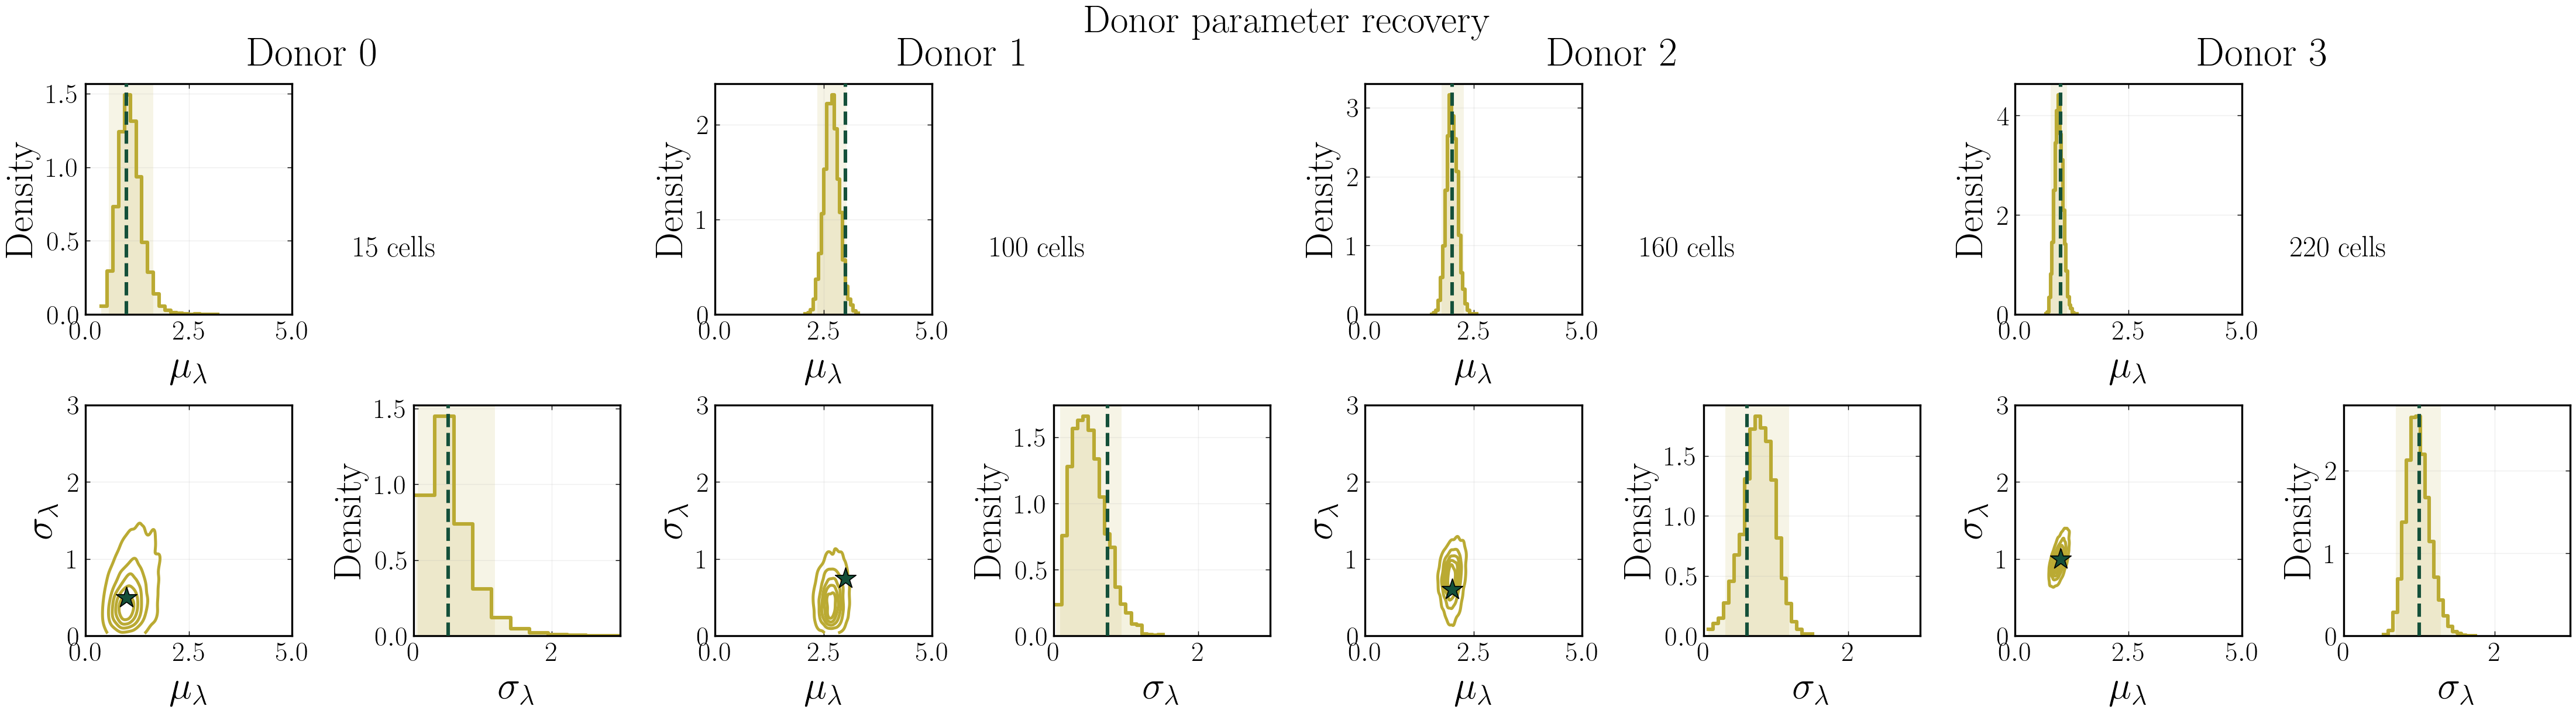

In [57]:
from pathlib import Path

POSTERIOR_COLOR = "#BAAA33"
TRUTH_COLOR = "#14503a"

# Shared limits for the population and all donor panels.
MU_LIMITS = (0.0, 5.0)
SIGMA_LIMITS = (0.0, 3)


def paired_rate_samples(
    mu_variable: str,
    sigma_variable: str,
    *,
    donor_index: int | None = None,
    sample_size: int | None = 6000,
    seed: int = 17,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Extract paired mu and sigma posterior samples.

    Pairing between mu and sigma from the same chain and draw
    is preserved.
    """
    mu = posterior_samples(
        mu_variable,
        donor_index,
    )

    sigma = posterior_samples(
        sigma_variable,
        donor_index,
    )

    keep = (
        np.isfinite(mu)
        & np.isfinite(sigma)
    )

    paired = np.column_stack(
        [
            mu[keep],
            sigma[keep],
        ]
    )

    if paired.shape[0] == 0:
        raise ValueError(
            "No finite paired posterior samples"
        )

    if (
        sample_size is not None
        and paired.shape[0] > sample_size
    ):
        rng = np.random.default_rng(seed)

        selected = rng.choice(
            paired.shape[0],
            size=sample_size,
            replace=False,
        )

        paired = paired[selected]

    return (
        paired[:, 0],
        paired[:, 1],
    )


def draw_recovery_triangle(
    axes: np.ndarray,
    mu_samples: np.ndarray,
    sigma_samples: np.ndarray,
    *,
    true_mu: float,
    true_sigma: float,
    mu_limits: tuple[float, float],
    sigma_limits: tuple[float, float],
    label_size: int = 18,
    tick_size: int = 13,
    hdi_prob: float = 0.95,
) -> None:
    """
    Draw marginal and joint posterior distributions.

    All plots use the supplied shared mu and sigma limits.
    """
    axes[0, 1].axis("off")

    marginal_settings = [
        (
            mu_samples,
            axes[0, 0],
            true_mu,
            r"$\mu_\lambda$",
        ),
        (
            sigma_samples,
            axes[1, 1],
            true_sigma,
            r"$\sigma_\lambda$",
        ),
    ]

    for (
        values,
        axis,
        truth,
        label,
    ) in marginal_settings:
        sns.histplot(
            values,
            bins=20,
            stat="density",
            element="step",
            fill=True,
            color=POSTERIOR_COLOR,
            alpha=0.15,
            linewidth=0,
            ax=axis,
        )

        sns.histplot(
            values,
            bins=20,
            stat="density",
            element="step",
            fill=False,
            color=POSTERIOR_COLOR,
            linewidth=2.2,
            ax=axis,
        )

        axis.axvline(
            truth,
            color=TRUTH_COLOR,
            linestyle="--",
            linewidth=2.2,
            zorder=5,
        )

        # Marginal posterior HDI.
        hdi_low, hdi_high = np.asarray(
            az.hdi(
                values,
                hdi_prob=hdi_prob,
            ),
            dtype=float,
        ).ravel()

        axis.axvspan(
            hdi_low,
            hdi_high,
            color=POSTERIOR_COLOR,
            alpha=0.12,
            linewidth=0,
            zorder=0,
        )

        axis.set_xlabel(
            label,
            fontsize=label_size,
        )

        axis.set_ylabel(
            "Density",
            fontsize=label_size,
        )

    # Joint posterior.
    sns.kdeplot(
        x=mu_samples,
        y=sigma_samples,
        levels=6,
        color=POSTERIOR_COLOR,
        linewidths=1.8,
        fill=False,
        cut=0,
        warn_singular=False,
        ax=axes[1, 0],
    )

    # Joint ground truth.
    axes[1, 0].scatter(
        true_mu,
        true_sigma,
        marker="*",
        s=180,
        color=TRUTH_COLOR,
        edgecolor="black",
        linewidth=0.6,
        zorder=5,
    )

    axes[1, 0].set_xlabel(
        r"$\mu_\lambda$",
        fontsize=label_size,
    )

    axes[1, 0].set_ylabel(
        r"$\sigma_\lambda$",
        fontsize=label_size,
    )

    # Apply identical parameter scales.
    axes[0, 0].set_xlim(
        *mu_limits
    )

    axes[1, 0].set_xlim(
        *mu_limits
    )

    axes[1, 1].set_xlim(
        *sigma_limits
    )

    axes[1, 0].set_ylim(
        *sigma_limits
    )

    for row, column in [
        (0, 0),
        (1, 0),
        (1, 1),
    ]:
        axis = axes[row, column]

        axis.tick_params(
            axis="both",
            labelsize=tick_size,
        )

        axis.minorticks_off()
        axis.grid(alpha=0.2)

        for spine in axis.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(1.2)


# ------------------------------------------------------------------
# Population parameter recovery
# ------------------------------------------------------------------

population_mu, population_sigma = paired_rate_samples(
    "mu_lambda_population",
    "sigma_lambda_population",
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(7, 7),
    dpi=200,
    constrained_layout=True,
)

draw_recovery_triangle(
    axes,
    population_mu,
    population_sigma,
    true_mu=TRUE_MU_LAMBDA_POPULATION,
    true_sigma=TRUE_SIGMA_LAMBDA_POPULATION,
    mu_limits=MU_LIMITS,
    sigma_limits=SIGMA_LIMITS,
)

fig.suptitle(
    "Population parameter recovery",
    fontsize=20,
)

fig.savefig(
    SVG_OUTPUT_DIR / "population_parameter_recovery_2.svg",
    format="svg",
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------------
# Donor-specific parameter recovery
# ------------------------------------------------------------------

fig = plt.figure(
    figsize=(
        5.5 * DONOR_NUM,
        5.8,
    ),
    dpi=200,
    constrained_layout=True,
)

subfigures = np.atleast_1d(
    fig.subfigures(
        1,
        DONOR_NUM,
        wspace=0.04,
    )
).ravel()

for (
    donor_index,
    (
        subfigure,
        donor_label,
    ),
) in enumerate(
    zip(
        subfigures,
        DONOR_LABELS,
    )
):
    axes = subfigure.subplots(
        2,
        2,
        squeeze=False,
    )

    mu_samples, sigma_samples = paired_rate_samples(
        "mu_lambda_donor",
        "sigma_lambda_donor",
        donor_index=donor_index,
        seed=17 + donor_index,
    )

    draw_recovery_triangle(
        axes,
        mu_samples,
        sigma_samples,
        true_mu=(
            TRUE_MU_LAMBDA_DONOR[
                donor_index
            ]
        ),
        true_sigma=(
            TRUE_SIGMA_LAMBDA_DONOR[
                donor_index
            ]
        ),
        mu_limits=MU_LIMITS,
        sigma_limits=SIGMA_LIMITS,
        label_size=24,
        tick_size=17,
    )

    # Cell count displayed as separate text.
    subfigure.text(
        0.7,
        0.7,
        f"{CELL_NUM_BY_DONOR[donor_index]} cells",
        ha="right",
        va="top",
        fontsize=18,
    )

    subfigure.suptitle(
        f"Donor {donor_label}",
        fontsize=25,
    )

fig.suptitle(
    "Donor parameter recovery",
    fontsize=24,
    y=1.04,
)

fig.savefig(
    SVG_OUTPUT_DIR / "donor_parameter_recovery_2.svg",
    format="svg",
    bbox_inches="tight",
)

plt.show()